# Genetic Algorithm 	
- Trình bày tổng quan về thuật toán
- Ứng dụng thuật toán giải quyết 1 bài toán tối ưu tổ hợp
- Đánh giá độ phức tạp thuật toán
- Cài đặt chương trình và chạy thực nghiệm thuật toán với một vài bộ dữ liệu đầu vào

## Phrase 1: Gain more knowledge about GA

In [1]:
"""
1 số thuật ngữ:
+ Cá thể - Individual: Là nhiễm sắc thể + thông tin bổ sung liên quan như fitness, probability of seleciton
+ Quần thể - Population
+ Nhiễm sắc thể - Chromosome
+ Gene
+ Độ thích nghi - Fitness 

Một chu trình của GA
Khởi tạo => Đánh giá => Chọn lọc => Chọn lọc => Lai ghép => Đột biến => Quyết định xem dừng lại hay tiếp tục
"""

'\n1 số thuật ngữ:\n+ Cá thể - Individual: Là nhiễm sắc thể + thông tin bổ sung liên quan như fitness, probability of seleciton\n+ Quần thể - Population\n+ Nhiễm sắc thể - Chromosome\n+ Gene\n+ Độ thích nghi - Fitness \n\nMột chu trình của GA\nKhởi tạo => Đánh giá => Chọn lọc => Chọn lọc => Lai ghép => Đột biến => Quyết định xem dừng lại hay tiếp tục\n'

## Phrase 2: Setup GA

In [1]:
import numpy as np 
import random 

class Individual:
    def __init__(self, chromosome):
        self.chromosome = chromosome
        self.fitness = 0.0

In [2]:
class GeneticAlgorithm:
    def __init__(self, pop_size, mutation_rate, elite_size, crossover_func, mutate_func, fitness_func, tournament_k=5):
        self.pop_size = pop_size
        self.mutation_rate = mutation_rate
        self.elite_size = elite_size
        self.crossover_func = crossover_func
        self.mutate_func = mutate_func
        self.fitness_func = fitness_func
        self.population = []
        self.tournament_k = tournament_k

    def create_initial_population(self, create_individual_func):
        for _ in range(self.pop_size):
            self.population.append(Individual(create_individual_func()))

    def evolve(self):
        # 1.Evaluate fitness
        for individual in self.population:
            individual.fitness = self.fitness_func(individual.chromosome)

        # 2.Arrange population
        self.population.sort(key=lambda x : x.fitness, reverse=True)

        # 3. Selection and create new population - Elitism
        new_population = self.population[:self.elite_size]

        while len(new_population) < self.pop_size:
            # Select parent
            parent1 = self.selection()
            parent2 = self.selection()

            # Crossover
            child_chromosome = self.crossover_func(parent1.chromosome, parent2.chromosome)

            # Mutation
            child_chromosome = self.mutate_func(child_chromosome)

            new_population.append(Individual(child_chromosome))

        self.population = new_population
    
    # Tourament Selection
    def selection(self):
        sample = random.sample(self.population, self.tournament_k)
        return max(sample, key=lambda x : x.fitness)

In [3]:
from random import sample
from random import random
#### Apply TSP - Traveling Salesman Problem
# def tsp_fitness(chromosome, distance_matrix):
#     total_distance = 0.0
#     for i in range(len(chromosome)):
#         start_node = chromosome[i]
#         end_node = chromosome[(i+1)%len(chromosome)]
#         total_distance += distance_matrix[start_node][end_node]

#     return 1/total_distance # The shorter path, the higher fitness value

# def tsp_mutate(chromosome, mutation_rate, mutation_type="inversion"):
#     if random.random() < mutation_rate:
#         if mutation_type == "swap":
#             i, j = sample(range(len(chromosome)), 2)
#             chromosome[i], chromosome[j] = chromosome[j], chromosome[i]
#         elif mutation_type == "inversion":
#             idx1, idx2 = sorted(sample(range(len(chromosome)), 2))
#             chromosome[idx1:idx2+1] = chromosome[idx1:idx2+1][::-1]
#         elif mutation_type == "scramble":
#             idx1, idx2 = sorted(sample(range(len(chromosome)), 2))
#             sub_section = chromosome[idx1:idx2+1]
#             random.shuffle(sub_section)
#             chromosome[idx1:idx2+1] = sub_section
#     return chromosome

def tsp_crossover_ox(parent1, parent2):
    size = len(parent1)

    # cut random array from parent1
    idx1, idx2 = sorted(sample(range(size), 2))
    child = [None] * size
    child[idx1:idx2+1] = parent1[idx1:idx2+1]

    # fill the rest of child with parent2
    genes_in_child = set(child[idx1:idx2+1])
    p2_pointer = (idx2+1)%size
    child_pointer = (idx2+1)%size
    
    item_added = 0
    while item_added < size - (idx2 - idx1 + 1):
        gene_from_p2 = parent2[p2_pointer]
        if gene_from_p2 not in genes_in_child:
            child[child_pointer] = gene_from_p2
            # genes_in_child.add(gene_from_p2)
            child_pointer = (child_pointer + 1) % size
            item_added += 1
        p2_pointer = (p2_pointer + 1) % size
    
    return child

def tsp_crossover_pmx(parent1, parent2):
    size = len(parent1)
    child = [None] * size
    idx1, idx2 = sorted(sample(range(size), 2))
    child[idx1:idx2+1] = parent1[idx1:idx2+1]

    # p2_pos[value] = position
    p2_pos = {v:k for k, v in enumerate(parent2)}

    for i in range(idx1, idx2+1):
        gene_p2 = parent2[i]

        if gene_p2 not in child[idx1:idx2+1]:
            # Find an empty position
            current_gene_p1 = parent1[i]
            target_idx = p2_pos[current_gene_p1]

            while idx1 <= target_idx <= idx2:
                new_gene_p1 = parent1[target_idx]
                target_idx = p2_pos[new_gene_p1]
            
            child[target_idx] = gene_p2

    for i in range(size):
        if child[i] is  None:
            child[i] = parent2[i]
    return child
            
def tsp_crossover_cx(parent1, parent2):
    size = len(parent1)
    child = [None] * size

    current_idx = 0
    while child[current_idx] is None:
        child[current_idx] = parent1[current_idx]
        val_in_p2 = parent2[current_idx]
        current_idx = parent1.index(val_in_p2)

    for i in range(size):
        if child[i] is None:
            child[i] = parent2[i]
    return child

In [ ]:
p1 = [1, 2, 3, 4, 5, 6, 7, 8]
p2 = [3, 7, 5, 1, 6, 8, 2, 4]
print(tsp_crossover_pmx(p1, p2))
print(tsp_crossover_ox(p1, p2))

[3, 7, 8, 4, 5, 6, 2, 1]
[7, 1, 8, 4, 5, 6, 2, 3]


In [17]:
print(tsp_crossover_cx(p1, p2))

[1, 7, 3, 4, 5, 6, 2, 8]


In [4]:
# Set up dict for crossover functions
CROSSOVER_FUNCS = {
    'ox': tsp_crossover_ox,
    'pmx': tsp_crossover_pmx,
    'cx': tsp_crossover_cx
}

# mutate function
def make_mutate_func(mutate_type, mutate_rate):
    def mutate(chromosome):
        if random.random() < mutate_rate:
            c = chromosome[:]
            if mutate_type == 'swap':
                i, j = sample(range(len(c)), 2)
                c[i], c[j] = c[j], c[i]
            elif mutate_type == 'inversion':
                i, j = sorted(sample(range(len(c)), 2))
                c[i:j+1] = c[i:j+1][::-1]
            elif mutate_type == 'scramble':
                i, j = sorted(sample(range(len(c)), 2))
                sub = c[i:j+1]
                random.shuffle(sub)
                c[i:j+1] = sub
            return c
        else:
            return chromosome
    return mutate


# fitness funtion factory
def make_fitness_function(distace_matrix):
    def fitness(chromosome):
        total = 0.0
        n = len(chromosome)
        for i in range(n):
            total += distace_matrix[chromosome[i]][chromosome[(i+1)%n]]
        return 1/total
    return fitness


## Phrase 3: Algorithm Complexity & Optimization

### 3.1. Phân tích Độ phức tạp Thời gian (Time Complexity)

Gọi các tham số:
- $N$ = Kích thước quần thể (Population size)
- $G$ = Số thế hệ tối đa (Generations)
- $n$ = Số thành phố (Chromosome length)
- $k$ = Kích thước Tournament

#### 3.1.1. Chi phí mỗi thế hệ

| Bước | Thao tác | Độ phức tạp |
|:-----|:---------|:------------|
| **Đánh giá Fitness** (`tsp_fitness`) | Duyệt toàn bộ $n$ gene trong chromosome | $O(N \cdot n)$ |
| **Sắp xếp quần thể** | Python `list.sort()` — Timsort | $O(N \log N)$ |
| **Tournament Selection** | Lấy mẫu $k$ phần tử, $N$ lần | $O(N \cdot k)$ |
| **Crossover (OX / PMX / CX)** | Cắt, fill, tra cứu trên chromosome | $O(N \cdot n)$ |
| **Mutation (Swap / Inversion / Scramble)** | Thao tác cục bộ trên slice | $O(N \cdot n)$ |

**Tổng độ phức tạp mỗi thế hệ:**

$$T_{\text{gen}} = O(N \cdot n + N \log N + N \cdot k) = O(N \cdot n)$$

> Với giả định $n \gg \log N$ và $n \gg k$ — điều này thường đúng trong TSP thực tế.

**Tổng độ phức tạp toàn bộ thuật toán:**

$$\boxed{T_{\text{GA}} = O(G \cdot N \cdot n)}$$

Với $G=500$, $N=100$, $n=52$ (berlin52): $\approx 2{,}600{,}000$ phép tính cơ bản — **rất khả thi trong thực tế.**

---

### 3.2. Phân tích Độ phức tạp Không gian (Space Complexity)

| Cấu trúc dữ liệu | Chi phí bộ nhớ |
|:-----------------|:---------------|
| Quần thể (`population`) — $N$ cá thể, mỗi cá thể $n$ gene | $O(N \cdot n)$ |
| Ma trận khoảng cách (`distance_matrix`) | $O(n^2)$ |
| Biến tạm (chromosome con, mảng tạm crossover) | $O(n)$ |

**Tổng:** $O(N \cdot n + n^2)$

---

### 3.3. Phân tích Chi tiết từng Toán tử

#### Crossover

| Toán tử | Cơ chế | Độ phức tạp | Điểm mạnh TSP |
|:--------|:-------|:------------|:--------------|
| **OX** (Ordered Crossover) | Copy đoạn P1 → fill tuần tự từ P2 (bỏ trùng) | $O(n)$ | Bảo tồn **thứ tự tương đối** — phù hợp nhất với TSP Euclidean |
| **PMX** (Partially Mapped) | Copy đoạn P1 → ánh xạ ngược P2 bằng dict | $O(n)$ avg | Bảo tồn **vị trí tuyệt đối** — phù hợp khi vị trí quan trọng |
| **CX** (Cycle Crossover) | Theo dõi vòng tròn (cycle) từ P1, P2 | $O(n)$ avg | Bảo tồn **vị trí tuyệt đối** của từng gene cùng lúc |

> **Lưu ý triển khai PMX:** Sử dụng dict `p2_pos = {v: k for k, v in enumerate(parent2)}` để tra cứu vị trí trong $O(1)$, giữ tổng phức tạp ở $O(n)$.

#### Mutation

| Toán tử | Cơ chế | Độ phức tạp | Tác động |
|:--------|:-------|:------------|:---------|
| **Swap** | Đổi chỗ 2 gene ngẫu nhiên | $O(1)$ | Thay đổi nhỏ, khám phá cục bộ |
| **Inversion** | Đảo ngược một đoạn con | $O(n)$ worst | Tương đương **2-opt** — loại giao điểm đường đi |
| **Scramble** | Xáo trộn một đoạn con ngẫu nhiên | $O(n)$ avg | Phá vỡ cấu trúc cục bộ mạnh hơn, tăng đa dạng |

---

### 3.4. Cơ chế Tối ưu đã Triển khai

#### A. Elitism
```python
new_population = self.population[:self.elite_size]
```
- **Tác dụng:** Đảm bảo cá thể tốt nhất không bao giờ bị mất (**monotone non-decreasing fitness**), giảm phương sai kết quả qua các lần chạy.
- **Độ phức tạp thêm:** $O(\text{elite\_size})$ — không đáng kể.

#### B. Tournament Selection (thay vì Roulette Wheel)
```python
def selection(self):
    sample = random.sample(self.population, 3)
    return max(sample, key=lambda x: x.fitness)
```
- **Ưu điểm:** Tạo áp lực chọn lọc có kiểm soát qua tham số $k$, **không bị chi phối** bởi cá thể siêu trội (dominant individual).
- **Tránh:** Hội tụ sớm (Premature Convergence) — vấn đề phổ biến của Roulette Wheel khi có cá thể có fitness vượt trội.

#### C. Hàm Fitness: Nghịch đảo khoảng cách
```python
return 1 / total_distance
```
- $f = 1/d_{\text{total}}$ → bài toán **tối thiểu hóa** khoảng cách được chuyển thành **tối đa hóa** fitness.
- Tương thích trực tiếp với cơ chế `sort(reverse=True)` và Tournament Selection.

---

### 3.5. So sánh với các Phương pháp khác trên TSP

| Thuật toán | Độ phức tạp | Chất lượng lời giải | Ghi chú |
|:-----------|:------------|:--------------------|:--------|
| **Brute Force** | $O(n!)$ | Tối ưu tuyệt đối | Chỉ áp dụng $n \leq 12$ |
| **Dynamic Programming (Held-Karp)** | $O(2^n \cdot n^2)$ | Tối ưu tuyệt đối | Áp dụng $n \leq 20$ |
| **Greedy (Nearest Neighbor)** | $O(n^2)$ | ~20–25% trên optimal | Nhanh, chất lượng thấp |
| **2-opt Local Search** | $O(n^2)$ / iteration | Tốt hơn Greedy | Dễ kẹt local optimum |
| **GA (cài đặt này)** | $O(G \cdot N \cdot n)$ | **~1–5% trên optimal** | Cân bằng tốt exploration/exploitation |

> **Kết luận Phrase 3:** GA không đảm bảo tối ưu tuyệt đối nhưng cung cấp lời giải **chất lượng cao trong thời gian đa thức** — đặc biệt phù hợp với TSP quy mô từ 50–200 thành phố nơi các phương pháp chính xác không khả thi.


## Phrase 4: Experiments

In [28]:
from numpy import dtype
# load dataset and build distance matrix

def load_tsplib(filepath):
    "Convert tsplib => coordinations list [(x, y), (..)]"
    coords = []
    with open(filepath, 'r') as f:
        reading = False
        for line in f:
            line = line.strip()
            if line == "NODE_COORD_SECTION":
                reading = True
                continue
            if line in ("EOF", ""):
                if reading:
                    break
                continue
            if reading:
                parts = line.strip().split()
                if len(parts) >= 3:
                    coords.append((float(parts[1]), float(parts[2])))
    return coords

def build_distance_matrix(coords):
    n = len(coords)
    dist_matrix = np.zeros((n, n), dtype=int)
    for i in range(n):
        for j in range(i+1, n):
            dx = coords[i][0] - coords[j][0]
            dy = coords[i][1] - coords[j][1]
            dist_matrix[i][j] = int(np.sqrt(dx*dx + dy*dy)+0.5) # nint
            dist_matrix[j][i] = dist_matrix[i][j]
    return dist_matrix

def build_distance_matrix_geo(coords):
    n = len(coords)
    dist = np.zeros((n, n))
    RRR = 6378.388 
    PI = 3.141592
    
    # Bước 1: Chuyển đổi tọa độ sang Radian theo chuẩn TSPLIB
    lat_lon_rad = []
    for i in range(n):
        deg_lat = int(coords[i][0])
        min_lat = coords[i][0] - deg_lat
        rad_lat = PI * (deg_lat + 5.0 * min_lat / 3.0) / 180.0
        
        deg_lon = int(coords[i][1])
        min_lon = coords[i][1] - deg_lon
        rad_lon = PI * (deg_lon + 5.0 * min_lon / 3.0) / 180.0
        lat_lon_rad.append((rad_lat, rad_lon))

    # Bước 2: Tính khoảng cách giữa các cặp điểm
    for i in range(n):
        for j in range(n):
            if i == j:
                dist[i][j] = 0
                continue
            
            q1 = np.cos(lat_lon_rad[i][1] - lat_lon_rad[j][1])
            q2 = np.cos(lat_lon_rad[i][0] - lat_lon_rad[j][0])
            q3 = np.cos(lat_lon_rad[i][0] + lat_lon_rad[j][0])
            
            # Công thức khoảng cách vòm (Great Circle Distance) của TSPLIB
            d = int(RRR * np.arccos(0.5 * ((1.0 + q1) * q2 - (1.0 - q1) * q3)) + 1.0)
            dist[i][j] = d
            
    return dist


def build_dist_matrix(coords, edge_weight_type="EUC_2D"):
    if edge_weight_type == "EUC_2D":
        return build_distance_matrix(coords)
    elif edge_weight_type == "GEO":
        return build_distance_matrix_geo(coords)

In [ ]:
# RUN WITH FIXED CONFIGURATIOn
import random 
def run_single_experiment(
    n_cities, dist_matrix,
    crossover_type='ox',
    mutation_type='inversion',
    pop_size=100,
    generation=500,
    mutation_rate=0.05,
    elite_size=1,
    tournament_k=5,
    seed=None):

    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    fitness_func = make_fitness_function(dist_matrix)
    crossover_func = CROSSOVER_FUNCS[crossover_type]
    mutation_func = make_mutate_func(mutation_type, mutation_rate)

    ga = GeneticAlgorithm(
        pop_size=pop_size,
        mutation_rate=mutation_rate,
        mutate_func=mutation_func,
        crossover_func=crossover_func,
        fitness_func=fitness_func,
        tournament_k=tournament_k,
        elite_size=elite_size
    )
    
    # create population
    ga.create_initial_population(lambda: random.sample(range(n_cities), n_cities))

    # run GA
    history = []
    for _ in range(generation):
        ga.evolve()
        for individual in ga.population:
            if individual.fitness == 0.0:
                individual.fitness = fitness_func(individual.chromosome)
        ga.population.sort(key=lambda x: x.fitness, reverse=True)
        history.append(round(1.0/ga.population[0].fitness, 2))

    best_cost = history[-1]
    best_chromosome = ga.population[0].chromosome[:]
    return best_cost, best_chromosome, history

In [29]:
DATASETS = {
    'burma14' : {'path': 'data/burma14.tsp',  'optimum': 3323, 'edge_weight_type': 'GEO'},
    'berlin52': {'path': 'data/berlin52.tsp',  'optimum': 7542, 'edge_weight_type': 'EUC_2D'},
    'kroA100' : {'path': 'data/kroA100.tsp',   'optimum': 21282, 'edge_weight_type': 'EUC_2D'},
}

loaded = {}
for name, info in DATASETS.items():
    try:
        coords = load_tsplib(info['path'])
        dist   = build_dist_matrix(coords, info['edge_weight_type'])
        loaded[name] = {'coords': coords, 'dist': dist, 'n': len(coords), 'optimum': info['optimum']}
        print(f"{name}: {len(coords)} cities| Known optimum: {info['optimum']}")
    except FileNotFoundError:
        print(f"{name}: File not found '{info['path']}'.")

burma14: 14 cities| Known optimum: 3323
berlin52: 52 cities| Known optimum: 7542
kroA100: 100 cities| Known optimum: 21282


In [8]:
BENCHMARK = 'berlin52'

# check benchmark
assert BENCHMARK in loaded, f"Dataset {BENCHMARK} not found!"

# load benchmark
coords_main = loaded[BENCHMARK]["coords"]
dist_main = loaded[BENCHMARK]["dist"]
N_CITIES = len(coords_main)
OPTIMUM = loaded[BENCHMARK]["optimum"]
print(f"Dataset: {BENCHMARK}")
print(f"Number of cities: {N_CITIES}")
print(f"Optimum: {OPTIMUM}")

Dataset: berlin52
Number of cities: 52
Optimum: 7542


In [11]:
# Pharse 1: Full Factorial Experiment 3x3 
import time

CROSSOVER_TYPES = ['ox', 'pmx', 'cx']
MUTATION_TYPES  = ['swap', 'inversion', 'scramble']
N_RUNS          = 30

results_phase1  = {}
histories_phase1 = {}

print("\n" + "=" * 65)
print("PHRASE 1: Full Factorial Design 3×3 — berlin52")
print(f"THE NUMBER OF RUNNING TIME: {len(CROSSOVER_TYPES) * len(MUTATION_TYPES) * N_RUNS}")
print("=" * 65)

for cx_type in CROSSOVER_TYPES:
    for mut_type in MUTATION_TYPES:
        key    = (cx_type, mut_type)
        costs  = []
        hists  = []
        t0     = time.time()

        for run in range(N_RUNS):
            cost, _, hist = run_single_experiment(
                n_cities=N_CITIES, dist_matrix=dist_main,
                crossover_type=cx_type, mutation_type=mut_type,
                pop_size=100, generation=500,
                mutation_rate=0.05, elite_size=1,
                tournament_k=5, seed=run
            )
            costs.append(cost)
            hists.append(hist)

        elapsed = time.time() - t0
        results_phase1[key]   = costs
        histories_phase1[key] = np.mean(hists, axis=0).tolist()

        best = min(costs)
        mean = np.mean(costs)
        std  = np.std(costs)
        gap  = (best - OPTIMUM) / OPTIMUM * 100
        print(f"[{cx_type.upper():3s}+{mut_type:10s}] "
              f"Best={best:7.1f} | Mean={mean:7.1f} | Std={std:6.1f} | "
              f"Gap={gap:+.2f}% | {elapsed:5.1f}s")

print("=" * 65)


PHRASE 1: Full Factorial Design 3×3 — berlin52
THE NUMBER OF RUNNING TIME: 270
[OX +swap      ] Best= 8395.0 | Mean= 9648.0 | Std= 527.0 | Gap=+11.31% |  67.9s
[OX +inversion ] Best= 8004.0 | Mean= 8509.2 | Std= 283.8 | Gap=+6.13% |  68.3s
[OX +scramble  ] Best= 9394.0 | Mean=10297.8 | Std= 701.9 | Gap=+24.56% |  68.5s
[PMX+swap      ] Best=10405.0 | Mean=11287.1 | Std= 478.0 | Gap=+37.96% |  71.6s
[PMX+inversion ] Best= 8216.0 | Mean= 8838.3 | Std= 363.9 | Gap=+8.94% |  71.6s
[PMX+scramble  ] Best=11511.0 | Mean=14140.1 | Std=1133.8 | Gap=+52.63% |  72.1s
[CX +swap      ] Best=10487.0 | Mean=11775.0 | Std= 691.5 | Gap=+39.05% |  59.4s
[CX +inversion ] Best= 8505.0 | Mean= 9174.1 | Std= 307.7 | Gap=+12.77% |  59.5s
[CX +scramble  ] Best=13771.0 | Mean=15500.4 | Std= 983.6 | Gap=+82.59% |  59.7s


/tmp/ipykernel_9762/2418254187.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(list(results_phase1.values()), labels=labels_box, patch_artist=True, showfliers=True)


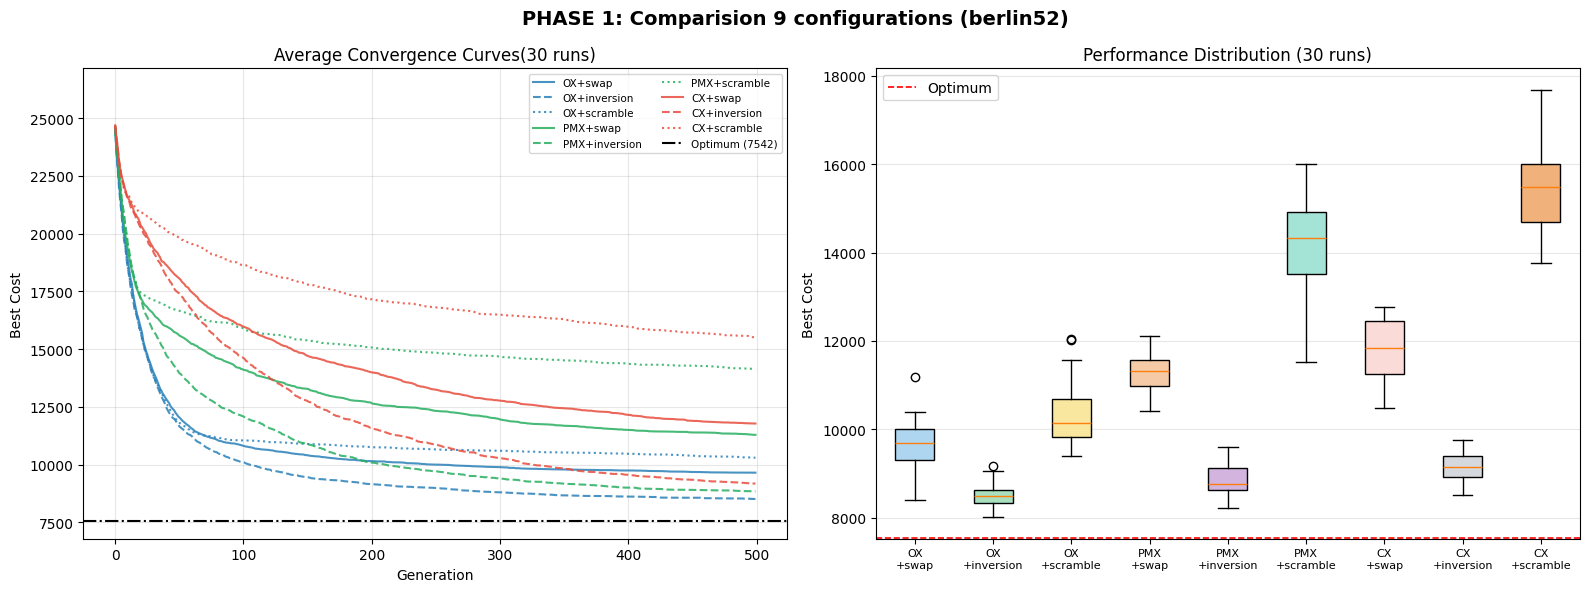

Saved: phase1_operator_comparison.png


In [19]:
import matplotlib.pyplot as plt 

# Create one row, 2 columns, with size 16 x 6 inch
fig, axes = plt.subplots(1, 2, figsize=(16, 6)) 
fig.suptitle('PHASE 1: Comparision 9 configurations (berlin52)', fontsize=14, fontweight='bold') # Head title

colors_cx  = {'ox': '#2980B9', 'pmx': '#27AE60', 'cx': '#E74C3C'}
styles_mut = {'swap': '-', 'inversion': '--', 'scramble': ':'}

ax1 = axes[0]
for (cx, mut), hist in histories_phase1.items():
    ax1.plot(hist, color=colors_cx[cx], linestyle=styles_mut[mut], linewidth=1.5, label=f'{cx.upper()}+{mut}', alpha=0.85)
ax1.axhline(y=OPTIMUM, color='black', linestyle='-.', linewidth=1.5, label=f'Optimum ({OPTIMUM})')
ax1.set_xlabel('Generation')
ax1.set_ylabel('Best Cost')
ax1.set_title('Average Convergence Curves(30 runs)')

all_hists = [h for h in histories_phase1.values()]
ax1.set_ylim(OPTIMUM * 0.9, np.max(all_hists) * 1.1)

ax1.legend(fontsize=7.5, ncol=2)
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
labels_box = [f'{cx.upper()}\n+{mut}' for (cx, mut) in results_phase1]
bp = ax2.boxplot(list(results_phase1.values()), labels=labels_box, patch_artist=True, showfliers=True)
palette = ['#AED6F1','#A9DFBF','#F9E79F','#F5CBA7','#D2B4DE','#A3E4D7','#FADBD8','#D5D8DC','#F0B27A']
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color)
ax2.axhline(y=OPTIMUM, color='red', linestyle='--', linewidth=1.2, label='Optimum')
ax2.set_ylabel('Best Cost')
ax2.set_title('Performance Distribution (30 runs)')

ax2.tick_params(axis='x', labelsize=8)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('phase1_operator_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: phase1_operator_comparison.png")

In [13]:
import pandas as pd

rows = []
for (cx, mut), costs in results_phase1.items():
    best = min(costs)
    rows.append({
        'Crossover': cx.upper(), 'Mutation': mut,
        'Best Cost': round(best, 1), 'Mean Cost': round(np.mean(costs), 1),
        'Std Dev':   round(np.std(costs), 1),
        'Gap (%)':   round((best - OPTIMUM) / OPTIMUM * 100, 3),
    })
df1 = pd.DataFrame(rows).sort_values('Best Cost').reset_index(drop=True)
print("\nTable of Results in Phrase 1:")
print(df1.to_string(index=False))

best_row       = df1.iloc[0]
BEST_CROSSOVER = best_row['Crossover'].lower()
BEST_MUTATION  = best_row['Mutation']
print(f"\n>>> Best configuration: [{BEST_CROSSOVER.upper()} + {BEST_MUTATION}]")


Table of Results in Phrase 1:
Crossover  Mutation  Best Cost  Mean Cost  Std Dev  Gap (%)
       OX inversion     8004.0     8509.2    283.8    6.126
      PMX inversion     8216.0     8838.3    363.9    8.937
       OX      swap     8395.0     9648.0    527.0   11.310
       CX inversion     8505.0     9174.1    307.7   12.768
       OX  scramble     9394.0    10297.8    701.9   24.556
      PMX      swap    10405.0    11287.1    478.0   37.961
       CX      swap    10487.0    11775.0    691.5   39.048
      PMX  scramble    11511.0    14140.1   1133.8   52.625
       CX  scramble    13771.0    15500.4    983.6   82.591

>>> Best configuration: [OX + inversion]


In [20]:
PM_LEVELS  = [0.01, 0.05, 0.20, 0.25, 0.30]

PM_LABELS  = {
    0.01: 'Pm=0.01 (Very Low)',
    0.05: 'Pm=0.05 (Low)',
    0.20: 'Pm=0.20 (Medium)',
    0.25: 'Pm=0.25 (High)',
    0.30: 'Pm=0.30 (Very High)'
}

PM_COLORS  = {
    0.01: '#E74C3C',   # red
    0.05: '#E67E22',   # orange
    0.20: '#2ECC71',   # green
    0.25: '#3498DB',   # blue
    0.30: '#9B59B6'    # purple
}

results_phase2  = {}
histories_phase2 = {}

print("\n" + "=" * 65)
print(f"PHASE 2: Pm Sensitivity Analysis — [{BEST_CROSSOVER.upper()} + {BEST_MUTATION}]")
print("=" * 65)

for pm in PM_LEVELS:
    costs = []
    hists = []
    for run in range(N_RUNS):
        cost, _, hist = run_single_experiment(
            n_cities=N_CITIES, dist_matrix=dist_main,
            crossover_type=BEST_CROSSOVER, mutation_type=BEST_MUTATION,
            pop_size=100, generation=500,
            mutation_rate=pm, elite_size=1, tournament_k=5, seed=run
        )
        costs.append(cost)
        hists.append(hist)

    results_phase2[pm]   = costs
    histories_phase2[pm] = np.mean(hists, axis=0).tolist()

    best = min(costs)
    gap  = (best - OPTIMUM) / OPTIMUM * 100
    print(f"{PM_LABELS[pm]:25s} | Best={best:7.1f} | "
          f"Mean={np.mean(costs):7.1f} | Std={np.std(costs):6.1f} | Gap={gap:+.2f}%")

print("=" * 65)


PHASE 2: Pm Sensitivity Analysis — [OX + inversion]
Pm=0.01 (Very Low)        | Best= 8689.0 | Mean= 9254.2 | Std= 343.9 | Gap=+15.21%
Pm=0.05 (Low)             | Best= 8004.0 | Mean= 8509.2 | Std= 283.8 | Gap=+6.13%
Pm=0.20 (Medium)          | Best= 7797.0 | Mean= 8177.0 | Std= 239.5 | Gap=+3.38%
Pm=0.25 (High)            | Best= 7748.0 | Mean= 8258.7 | Std= 282.1 | Gap=+2.73%
Pm=0.30 (Very High)       | Best= 7732.0 | Mean= 8190.5 | Std= 267.6 | Gap=+2.52%


/tmp/ipykernel_9762/3269716464.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax2.boxplot(


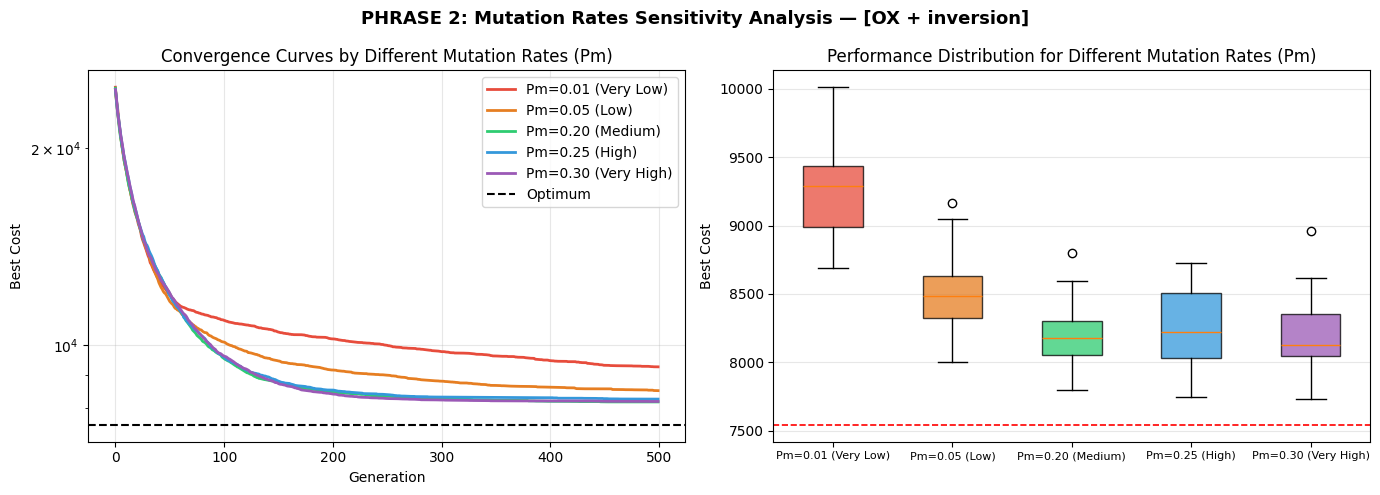

Đã lưu: phase2_sensitivity_pm.png


In [36]:
# ---- Trực quan hóa GĐ2 ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'PHRASE 2: Mutation Rates Sensitivity Analysis — [{BEST_CROSSOVER.upper()} + {BEST_MUTATION}]', fontsize=13, fontweight='bold')

ax1 = axes[0]
for pm, hist in histories_phase2.items():
    ax1.plot(hist, color=PM_COLORS[pm], linewidth=2, label=PM_LABELS[pm])
ax1.axhline(y=OPTIMUM, color='black', linestyle='--', linewidth=1.5, label='Optimum')
ax1.set_xlabel('Generation')
ax1.set_ylabel('Best Cost')
ax1.set_title('Convergence Curves by Different Mutation Rates (Pm)')

# all_hists = [h for h in histories_phase2.values()]
# ax1.set_ylim(OPTIMUM * 0.9, np.max(all_hists) * 1.1)
ax1.set_yscale('log')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
bp2 = ax2.boxplot(
    [results_phase2[pm] for pm in PM_LEVELS],
    labels=[PM_LABELS[pm] for pm in PM_LEVELS],
    patch_artist=True
)
for patch, pm in zip(bp2['boxes'], PM_LEVELS):
    patch.set_facecolor(PM_COLORS[pm])
    patch.set_alpha(0.75)
ax2.axhline(y=OPTIMUM, color='red', linestyle='--', linewidth=1.2)
ax2.set_ylabel('Best Cost')
ax2.set_title('Performance Distribution for Different Mutation Rates (Pm)')
ax2.tick_params(axis='x', labelsize=8)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('phase2_sensitivity_pm.png', dpi=150, bbox_inches='tight')
plt.show()
print("Đã lưu: phase2_sensitivity_pm.png")

In [37]:
# ============================================================
# GIAI ĐOẠN 3: Scalability Test
# Dataset: burma14, berlin52, kroA100
# Cấu hình: best từ GĐ1, Pm=0.05
# ============================================================

results_phase3 = {}

print("\n" + "=" * 65)
print(f"PHRASE 3: Scalability Test — [{BEST_CROSSOVER.upper()} + {BEST_MUTATION}]")
print("=" * 65)

for ds_name, ds_info in loaded.items():
    n       = ds_info['n']
    dist_m  = ds_info['dist']
    opt     = ds_info['optimum']
    gens    = 300 if n <= 20 else 500   # Ít hơn cho dataset nhỏ

    costs = []
    t0 = time.time()
    for run in range(N_RUNS):
        cost, _, _ = run_single_experiment(
            n_cities=n, dist_matrix=dist_m,
            crossover_type=BEST_CROSSOVER, mutation_type=BEST_MUTATION,
            pop_size=100, generation=gens,
            mutation_rate=0.25, elite_size=1, tournament_k=5, seed=run
        )
        costs.append(cost)

    elapsed = time.time() - t0
    best = min(costs)
    gap  = (best - opt) / opt * 100
    results_phase3[ds_name] = {
        'n': n, 'costs': costs, 'best': best,
        'mean': np.mean(costs), 'std': np.std(costs),
        'gap': gap, 'optimum': opt, 'time': elapsed,
    }
    print(f"{ds_name:10s} ({n:3d} TP) | "
          f"Best={best:8.1f} | Gap={gap:+.2f}% | "
          f"Std={np.std(costs):7.1f} | {elapsed:6.1f}s")

print("=" * 65)


PHRASE 3: Scalability Test — [OX + inversion]
burma14    ( 14 TP) | Best=  3323.0 | Gap=+0.00% | Std=   31.6 |   15.4s
berlin52   ( 52 TP) | Best=  7748.0 | Gap=+2.73% | Std=  282.1 |   67.9s
kroA100    (100 TP) | Best= 23904.0 | Gap=+12.32% | Std= 1138.7 |  114.7s


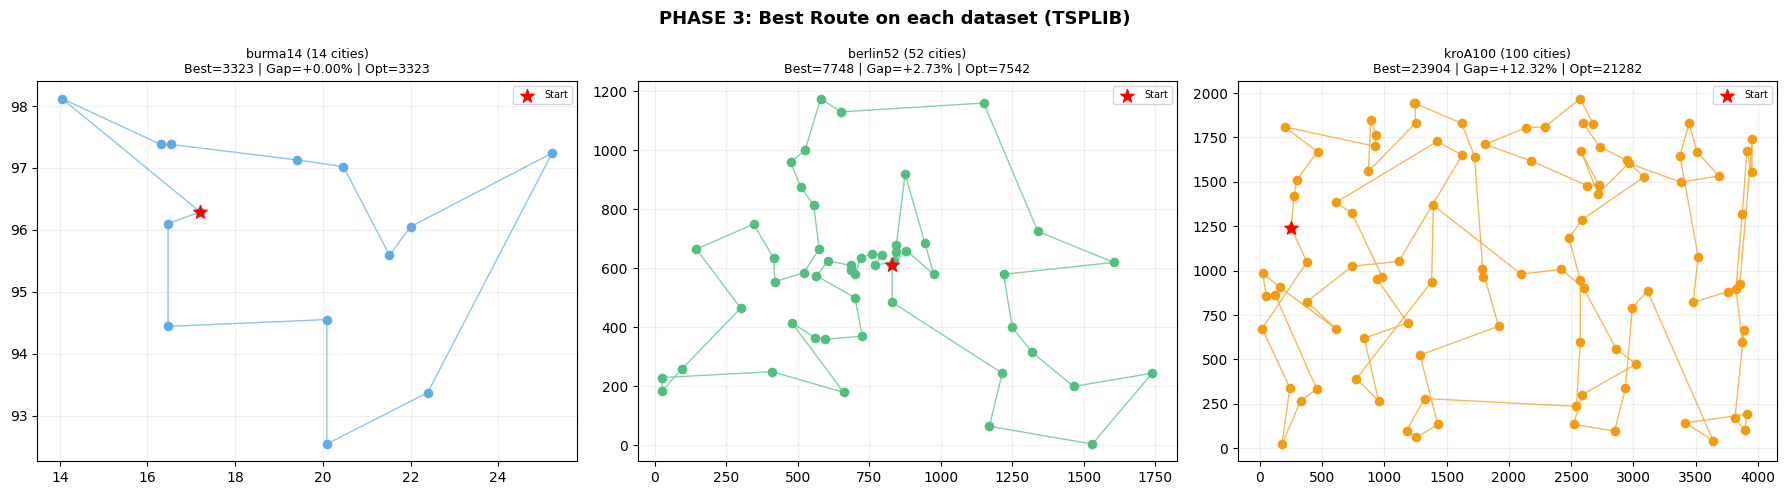

Đã lưu: phase3_scalability_routes.png


In [ ]:
# ---- Trực quan hóa GĐ3: Tọa độ thành phố + Route ----
n_plots = len(results_phase3)
fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5))
if n_plots == 1:
    axes = [axes]
fig.suptitle('PHASE 3: Best Route on each dataset (TSPLIB)', fontsize=13, fontweight='bold')

bar_colors = ['#5DADE2', '#52BE80', '#F39C12']
for idx, (ds_name, info) in enumerate(results_phase3.items()):
    ax = axes[idx]
    coords  = loaded[ds_name]['coords']
    dist_m  = loaded[ds_name]['dist']
    n_c     = info['n']
    opt     = info['optimum']

    # Lấy best route bằng cách chạy lại với seed tốt nhất
    best_seed = int(np.argmin(info['costs']))
    _, _, best_route = run_single_experiment(
        n_cities=n_c, dist_matrix=dist_m,
        crossover_type=BEST_CROSSOVER, mutation_type=BEST_MUTATION,
        pop_size=100, generation=300 if n_c <= 20 else 500,
        mutation_rate=0.05, seed=best_seed
    )

    xs = [coords[c][0] for c in best_route] + [coords[best_route[0]][0]]
    ys = [coords[c][1] for c in best_route] + [coords[best_route[0]][1]]

    ax.plot(xs, ys, '-', color=bar_colors[idx], linewidth=1.0, alpha=0.7)
    ax.scatter([c[0] for c in coords], [c[1] for c in coords],
               s=35, color=bar_colors[idx], zorder=5)
    ax.scatter([coords[best_route[0]][0]], [coords[best_route[0]][1]],
               s=100, color='red', zorder=6, marker='*', label='Start')

    ax.set_title(
        f"{ds_name} ({n_c} cities)\n"
        f"Best={info['best']:.0f} | Gap={info['gap']:+.2f}% | Opt={opt}",
        fontsize=9
    )
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('phase3_scalability_routes.png', dpi=150, bbox_inches='tight')
plt.show()
print("Đã lưu: phase3_scalability_routes.png")

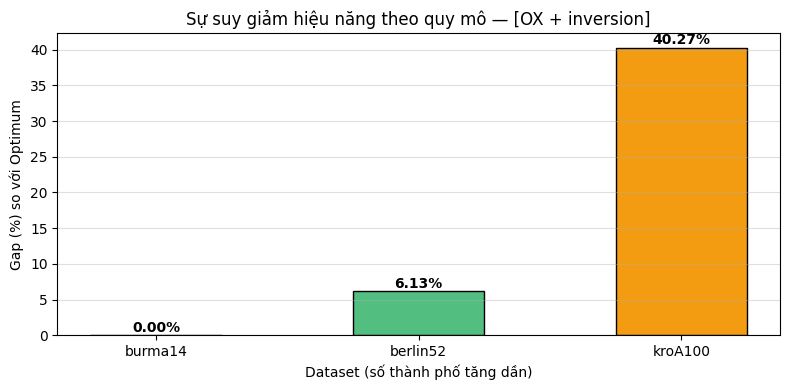

Đã lưu: phase3_scalability_gap.png


In [32]:
# ---- Biểu đồ Gap theo quy mô ----
ds_names = list(results_phase3.keys())
n_sizes  = [results_phase3[d]['n']   for d in ds_names]
gaps     = [results_phase3[d]['gap'] for d in ds_names]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(ds_names, gaps, color=bar_colors[:len(ds_names)], edgecolor='black', width=0.5)
for bar, gap in zip(bars, gaps):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{gap:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_xlabel('Dataset (số thành phố tăng dần)')
ax.set_ylabel('Gap (%) so với Optimum')
ax.set_title(f'Sự suy giảm hiệu năng theo quy mô — [{BEST_CROSSOVER.upper()} + {BEST_MUTATION}]')
ax.grid(True, axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('phase3_scalability_gap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Đã lưu: phase3_scalability_gap.png")

In [26]:
# ============================================================
# TỔNG KẾT: Kiểm chứng các Giả thuyết
# ============================================================

print("\n" + "=" * 65)
print("KIỂM CHỨNG GIẢ THUYẾT")
print("=" * 65)

# H1: OX tốt hơn PMX và CX (trung bình Best Cost thấp hơn)
avg_best = {cx: np.mean([min(results_phase1[(cx, m)]) for m in MUTATION_TYPES])
            for cx in CROSSOVER_TYPES}
h1_ok = avg_best['ox'] <= avg_best['pmx'] and avg_best['ox'] <= avg_best['cx']
print(f"\nH1 — OX tốt nhất về Best Cost: {'✅ ĐÚNG' if h1_ok else '❌ SAI'}")
for cx in CROSSOVER_TYPES:
    print(f"   {cx.upper()} avg best: {avg_best[cx]:.1f}")

# H2: Inversion tốt hơn Swap và Scramble
avg_mut = {m: np.mean([min(results_phase1[(cx, m)]) for cx in CROSSOVER_TYPES])
           for m in MUTATION_TYPES}
h2_ok = avg_mut['inversion'] <= avg_mut['swap'] and avg_mut['inversion'] <= avg_mut['scramble']
print(f"\nH2 — Inversion tốt nhất về Best Cost: {'✅ ĐÚNG' if h2_ok else '❌ SAI'}")
for m in MUTATION_TYPES:
    print(f"   {m:10s} avg best: {avg_mut[m]:.1f}")

# H3: [OX + Inversion] có Std Dev thấp nhất
all_stds = {k: np.std(v) for k, v in results_phase1.items()}
min_key  = min(all_stds, key=all_stds.get)
h3_ok    = min_key == ('ox', 'inversion')
std_ox_inv = all_stds.get(('ox', 'inversion'), float('inf'))
print(f"\nH3 — [OX+Inversion] ổn định nhất (Std thấp nhất): {'✅ ĐÚNG' if h3_ok else '❌ SAI'}")
print(f"   Std [OX+Inversion]    : {std_ox_inv:.2f}")
print(f"   Cấu hình Std thấp nhất: {min_key} = {all_stds[min_key]:.2f}")

print("\n" + "=" * 65)
print("KẾT LUẬN CHUNG")
print("=" * 65)
print(f"Cấu hình tốt nhất từ thực nghiệm: [{BEST_CROSSOVER.upper()} + {BEST_MUTATION}]")
print("\nScalability (Gap so với Optimum TSPLIB):")
for ds_name, info in results_phase3.items():
    print(f"  {ds_name:10s} ({info['n']:3d} TP): "
          f"Best={info['best']:.0f} | Gap={info['gap']:+.2f}% | Optimum={info['optimum']}")
print("=" * 65)


KIỂM CHỨNG GIẢ THUYẾT

H1 — OX tốt nhất về Best Cost: ✅ ĐÚNG
   OX avg best: 8597.7
   PMX avg best: 10044.0
   CX avg best: 10921.0

H2 — Inversion tốt nhất về Best Cost: ✅ ĐÚNG
   swap       avg best: 9762.3
   inversion  avg best: 8241.7
   scramble   avg best: 11558.7

H3 — [OX+Inversion] ổn định nhất (Std thấp nhất): ✅ ĐÚNG
   Std [OX+Inversion]    : 283.83
   Cấu hình Std thấp nhất: ('ox', 'inversion') = 283.83

KẾT LUẬN CHUNG
Cấu hình tốt nhất từ thực nghiệm: [OX + inversion]

Scalability (Gap so với Optimum TSPLIB):
  burma14    ( 14 TP): Best=30 | Gap=-99.10% | Optimum=3323
  berlin52   ( 52 TP): Best=8004 | Gap=+6.13% | Optimum=7542
  kroA100    (100 TP): Best=29852 | Gap=+40.27% | Optimum=21282
